## Human lung cancer perturbation summaries

Review `BASE_DIR` and result paths below to select the runs to compare.


In [1]:
from pathlib import Path
import os, sys, glob, json, inspect, copy
sys.dont_write_bytecode = True
EXPERIMENT_DIR = next(q for p in [Path.cwd(), *Path.cwd().parents] for q in [p, p/'human_lung_cancer', p/'experiments/human_lung_cancer'] if q.name == 'human_lung_cancer' and (q/'perturb/config.yaml').is_file())
PERTURB_DIR = EXPERIMENT_DIR / 'perturb'
sys.path.insert(0, str(EXPERIMENT_DIR.parents[1] / 'src'))
from stvirtual.perturb import prepare_runtime
prepare_runtime(EXPERIMENT_DIR)
import scanpy as sc
import torch
import numpy as np
import pandas as pd
import anndata as ad
import scvi
import scipy.sparse as sp
from scipy import sparse
import torch.nn.functional as F
import matplotlib.pyplot as plt
from stvirtual.perturb import PerturbationSession, read_frames, find_gene_name
session = PerturbationSession('LUAD', config_path=PERTURB_DIR/'config.yaml')
paths = session.paths

import pandas as pd


In [2]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def load_all_diag(base_dir, csv_name="diag_piece1.csv", exclude_dirs=("results",)):
    """
    Read diag_piece1.csv from each subfolder of base_dir.
    Exclude folders listed in exclude_dirs.
    Returns: dict[folder_name] = diag_df
    """
    base_dir = Path(base_dir)
    diag_dict = {}

    for sub in base_dir.iterdir():
        if not sub.is_dir():
            continue
        if sub.name in exclude_dirs:
            continue

        csv_path = sub / csv_name
        if csv_path.exists():
            df = pd.read_csv(csv_path)
            diag_dict[sub.name] = df

    return diag_dict


def sort_folder_names(names):
    """
    Sorting rules:
    Place origin first.
    Sort top10_results, top30_results, ... by increasing number.
    Place other entries last.
    """
    def key_fn(x):
        if x == "origin":
            return (0, 0)

        m = re.match(r"top(\d+)_results", x)
        if m:
            return (1, int(m.group(1)))

        return (2, x)

    return sorted(names, key=key_fn)


def plot_prop_multi_clean(
    diag_dict,
    t_col="t_step",
    prop_col="prop_alpha_gt_0.6",
    figsize=(7.2, 5.2),
    dpi=180,
    ylim=(0, 0.6),
    title=None,
):
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    folder_names = sort_folder_names(list(diag_dict.keys()))
    colors = plt.cm.tab10(np.linspace(0, 1, len(folder_names)))

    for i, name in enumerate(folder_names):
        diag_df = diag_dict[name].copy()

        x = pd.to_numeric(diag_df[t_col], errors="coerce").to_numpy()
        y = pd.to_numeric(diag_df[prop_col], errors="coerce").to_numpy()

        ok = np.isfinite(x) & np.isfinite(y)
        x = x[ok]
        y = y[ok]

        if len(x) == 0:
            continue

        # Use a slightly thicker line for origin.
        lw = 2.6 if name == "origin" else 2.0
        alpha = 1.0 if name == "origin" else 0.9

        ax.plot(
            x, y,
            label=name,
            lw=lw,
            alpha=alpha,
            color=colors[i],
            zorder=3
        )

    ax.set_xlabel("t", fontsize=12)
    ax.set_ylabel("proportion", fontsize=12)
    ax.set_title(title if title is not None else prop_col, fontsize=15, pad=8)
    ax.set_ylim(*ylim)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.0)
    ax.spines["bottom"].set_linewidth(1.0)
    ax.tick_params(axis="both", labelsize=10)

    ax.legend(frameon=False, fontsize=9, ncol=2)
    plt.tight_layout()
    plt.show()

## Load simulation summaries

Read the saved diagnostics for each condition.


dict_keys(['top50_results', 'origin', 'top70_results', 'top10_results', 'top30_results', 'top90_results', 'top100_results'])


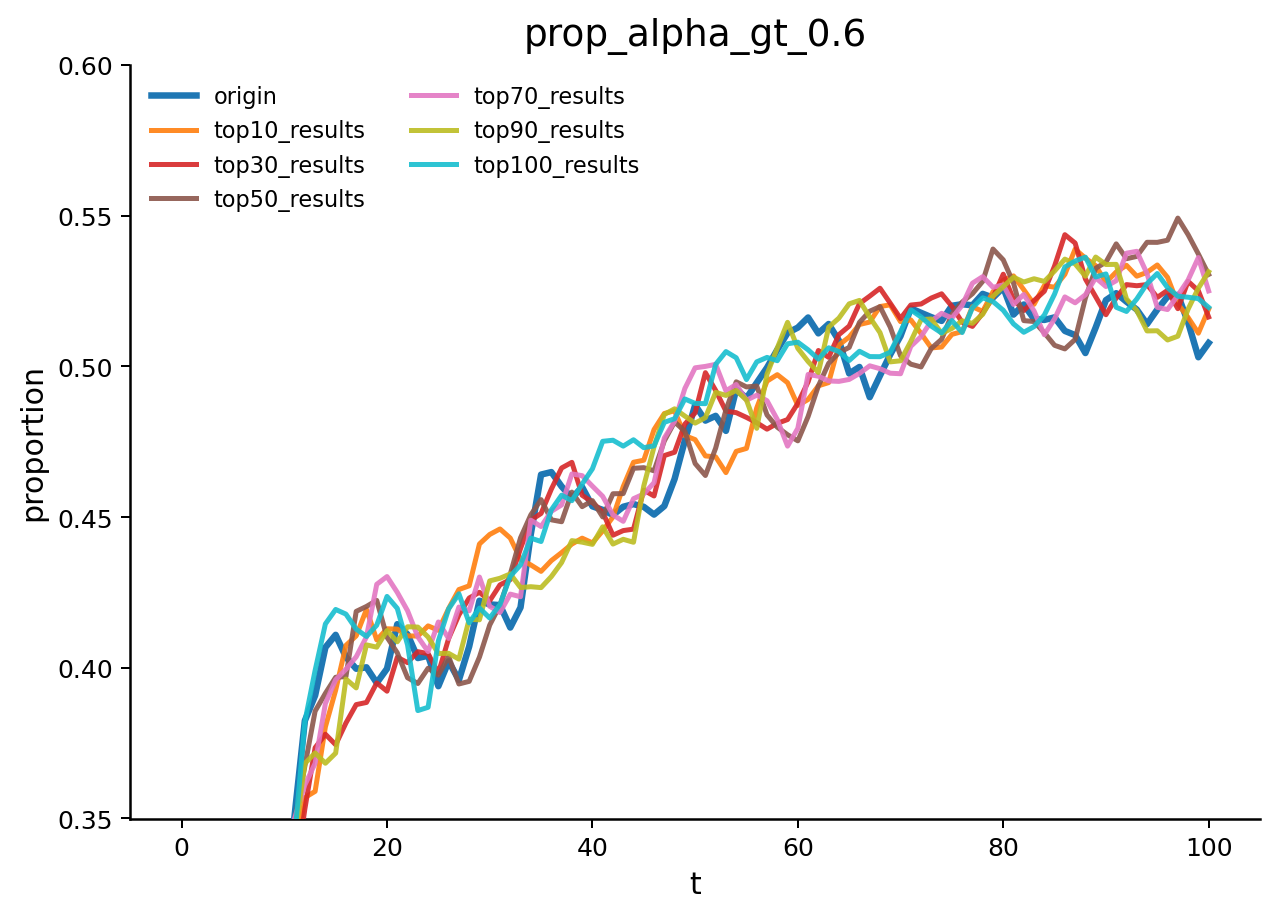

In [3]:
BASE_DIR = str(EXPERIMENT_DIR / "artifacts/perturb")   # Root directory for perturbation results.

diag_dict = load_all_diag(
    base_dir=BASE_DIR,
    csv_name="diag_piece1.csv",
    exclude_dirs=("results",)
)

print(diag_dict.keys())  # Inspect the loaded runs.

plot_prop_multi_clean(
    diag_dict,
    t_col="t_step",
    prop_col="prop_alpha_gt_0.6",
    title="prop_alpha_gt_0.6",
    ylim=(0.35, 0.6),
)

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_prop_summary_vs_origin(
    diag_dict,
    t_col="t_step",
    prop_col="prop_alpha_gt_0.6",
    figsize=(7.4, 5.0),
    dpi=180,
    ylim=(0.35, 0.56),
):
    # ---- Select origin.
    if "origin" not in diag_dict:
        raise ValueError("diag_dict must contain 'origin'")

    origin_df = diag_dict["origin"].copy()
    x0 = pd.to_numeric(origin_df[t_col], errors="coerce").to_numpy()
    y0 = pd.to_numeric(origin_df[prop_col], errors="coerce").to_numpy()
    ok0 = np.isfinite(x0) & np.isfinite(y0)
    x0, y0 = x0[ok0], y0[ok0]

    # ---- Collect the other topXX runs.
    ys = []
    names = []
    for name, df in diag_dict.items():
        if name == "origin":
            continue

        x = pd.to_numeric(df[t_col], errors="coerce").to_numpy()
        y = pd.to_numeric(df[prop_col], errors="coerce").to_numpy()
        ok = np.isfinite(x) & np.isfinite(y)
        x, y = x[ok], y[ok]

        # Assume aligned time points; use a merge for unaligned series.
        if len(x) == len(x0) and np.allclose(x, x0):
            ys.append(y)
            names.append(name)

    Y = np.vstack(ys)  # shape = (n_curve, n_t)

    y_mean = Y.mean(axis=0)
    y_q25  = np.quantile(Y, 0.25, axis=0)
    y_q75  = np.quantile(Y, 0.75, axis=0)
    y_min  = Y.min(axis=0)
    y_max  = Y.max(axis=0)

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    # Other curves: light gray.
    for y in Y:
        ax.plot(x0, y, color="0.75", lw=1.2, alpha=0.8, zorder=1)

    # Min-max band.
    ax.fill_between(x0, y_min, y_max, color="#f4b183", alpha=0.18, zorder=0)

    # IQR band.
    ax.fill_between(x0, y_q25, y_q75, color="#ed7d31", alpha=0.28, zorder=2)

    # Mean curve across topXX runs.
    ax.plot(x0, y_mean, color="#c55a11", lw=2.6, label="topXX mean", zorder=3)

    # Highlight origin.
    ax.plot(x0, y0, color="#1f4e79", lw=2.8, label="origin", zorder=4)

    ax.set_xlabel("t", fontsize=12)
    ax.set_ylabel("proportion", fontsize=12)
    ax.set_title(prop_col, fontsize=16, pad=8)
    ax.set_ylim(*ylim)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False, fontsize=10)
    ax.tick_params(axis="both", labelsize=10)

    plt.tight_layout()
    plt.show()

## Compare conditions

Plot transition proportions and evaluate differences from the baseline.


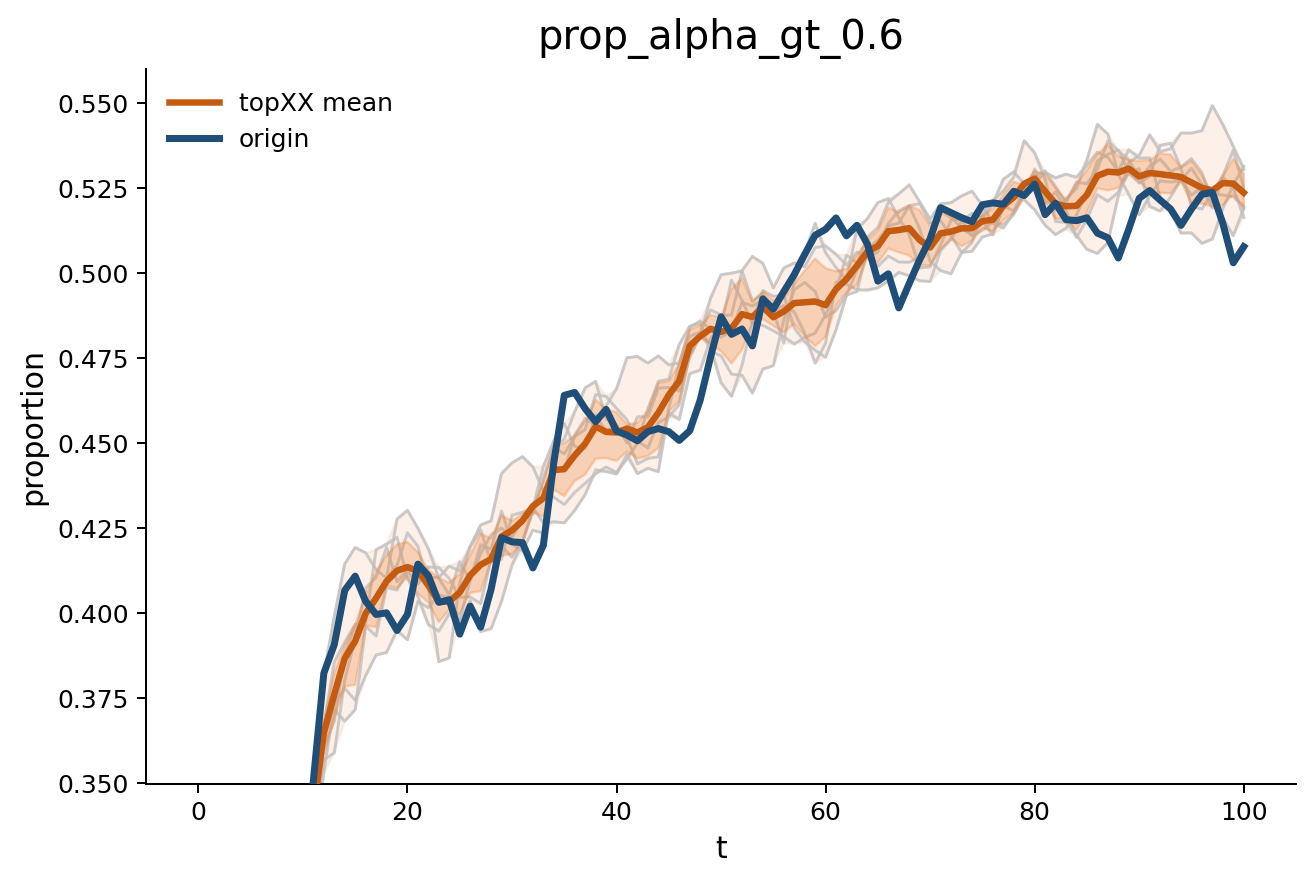

In [5]:
plot_prop_summary_vs_origin(
    diag_dict,
    t_col="t_step",
    prop_col="prop_alpha_gt_0.6",
    ylim=(0.35, 0.56),
)

In [6]:
def plot_prop_delta_from_origin(
    diag_dict,
    t_col="t_step",
    prop_col="prop_alpha_gt_0.6",
    figsize=(7.4, 4.8),
    dpi=180,
    ylim=(-0.03, 0.03),
):
    if "origin" not in diag_dict:
        raise ValueError("diag_dict must contain 'origin'")

    origin_df = diag_dict["origin"].copy()
    x0 = pd.to_numeric(origin_df[t_col], errors="coerce").to_numpy()
    y0 = pd.to_numeric(origin_df[prop_col], errors="coerce").to_numpy()
    ok0 = np.isfinite(x0) & np.isfinite(y0)
    x0, y0 = x0[ok0], y0[ok0]

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    deltas = []

    for name, df in diag_dict.items():
        if name == "origin":
            continue

        x = pd.to_numeric(df[t_col], errors="coerce").to_numpy()
        y = pd.to_numeric(df[prop_col], errors="coerce").to_numpy()
        ok = np.isfinite(x) & np.isfinite(y)
        x, y = x[ok], y[ok]

        if len(x) == len(x0) and np.allclose(x, x0):
            delta = y - y0
            deltas.append(delta)
            ax.plot(x0, delta, lw=1.5, alpha=0.8, label=name)

    if len(deltas) > 0:
        D = np.vstack(deltas)
        d_mean = D.mean(axis=0)
        d_q25 = np.quantile(D, 0.25, axis=0)
        d_q75 = np.quantile(D, 0.75, axis=0)

        ax.fill_between(x0, d_q25, d_q75, alpha=0.18, zorder=1)
        ax.plot(x0, d_mean, color="black", lw=2.4, label="mean delta", zorder=3)

    ax.axhline(0, color="0.3", ls="--", lw=1.3)

    ax.set_xlabel("t", fontsize=12)
    ax.set_ylabel("delta vs origin", fontsize=12)
    ax.set_title(f"{prop_col} - origin", fontsize=16, pad=8)
    ax.set_ylim(*ylim)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False, fontsize=9, ncol=2)
    ax.tick_params(axis="both", labelsize=10)

    plt.tight_layout()
    plt.show()

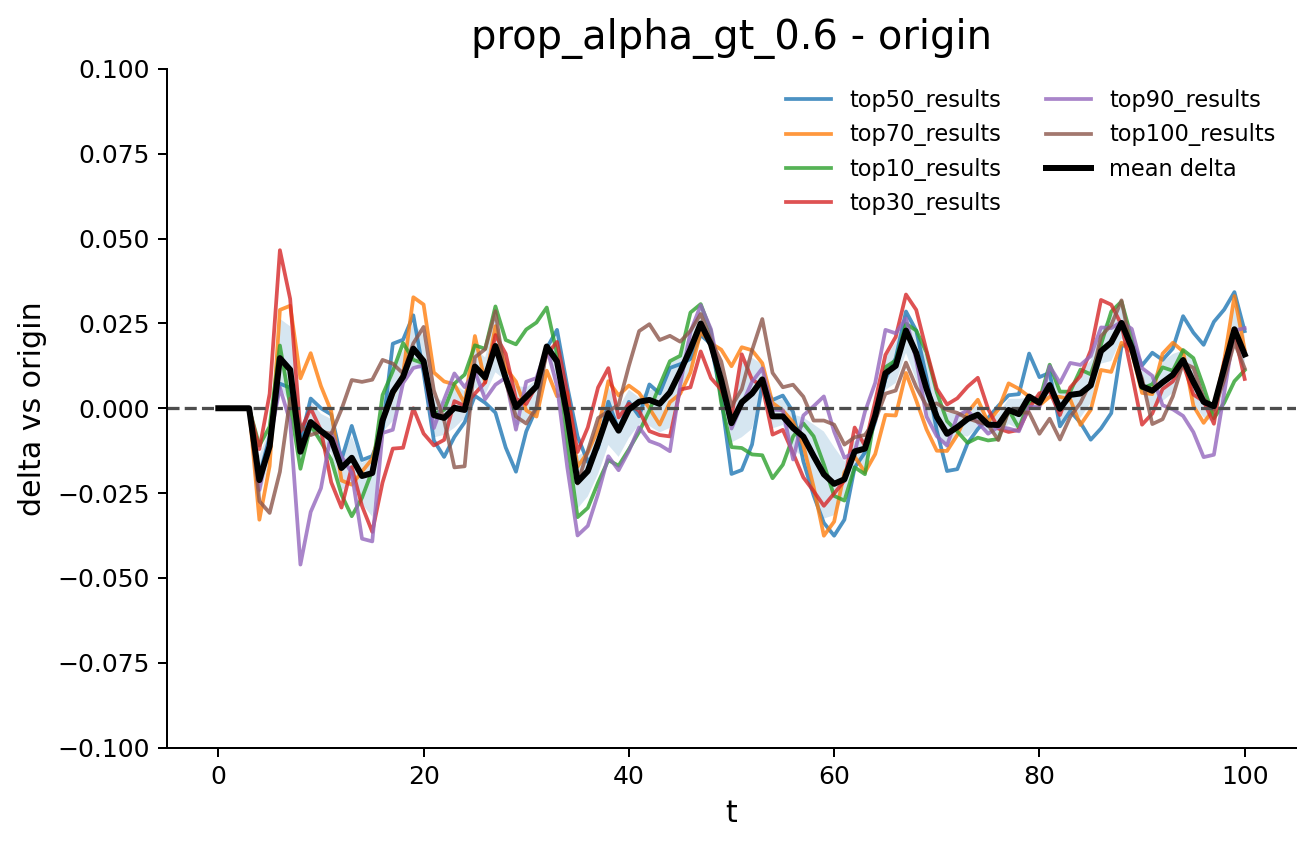

In [7]:
plot_prop_delta_from_origin(
    diag_dict,
    t_col="t_step",
    prop_col="prop_alpha_gt_0.6",
    figsize=(7.4, 4.8),
    dpi=180,
    ylim=(-0.1, 0.1),
)

In [8]:
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon, ttest_rel
from statsmodels.stats.multitest import multipletests


def test_lower_than_origin(
    diag_dict,
    t_col="t_step",
    prop_col="prop_alpha_gt_0.6",
    origin_name="origin",
    exclude_zero_diff=True,
):
    """
    Run a one-sided paired test for each curve against origin:
        H0: test >= origin
        H1: test < origin

    Return a results table:
    - mean_delta = mean(test - origin)
    - median_delta
    - frac_lower = fraction of time points below origin
    - p_wilcox = one-sided paired Wilcoxon p-value
    - p_ttest = one-sided paired t-test p-value (secondary)
    - fdr_wilcox / fdr_ttest
    """

    if origin_name not in diag_dict:
        raise ValueError(f"diag_dict does not contain {origin_name!r}")

    # --- origin ---
    origin_df = diag_dict[origin_name].copy()
    origin_df = origin_df[[t_col, prop_col]].copy()
    origin_df[t_col] = pd.to_numeric(origin_df[t_col], errors="coerce")
    origin_df[prop_col] = pd.to_numeric(origin_df[prop_col], errors="coerce")
    origin_df = origin_df.dropna().rename(columns={prop_col: "origin_value"})

    rows = []

    for name, df in diag_dict.items():
        if name == origin_name:
            continue

        sub = df[[t_col, prop_col]].copy()
        sub[t_col] = pd.to_numeric(sub[t_col], errors="coerce")
        sub[prop_col] = pd.to_numeric(sub[prop_col], errors="coerce")
        sub = sub.dropna().rename(columns={prop_col: "test_value"})

        m = pd.merge(origin_df, sub, on=t_col, how="inner").sort_values(t_col)
        if len(m) < 3:
            rows.append({
                "name": name,
                "n_t": len(m),
                "mean_delta": np.nan,
                "median_delta": np.nan,
                "frac_lower": np.nan,
                "p_wilcox": np.nan,
                "p_ttest": np.nan,
                "note": "too few matched t"
            })
            continue

        x = m["test_value"].to_numpy(dtype=float)
        y = m["origin_value"].to_numpy(dtype=float)
        delta = x - y

        if exclude_zero_diff:
            delta_nz = delta[delta != 0]
            x_nz = x[delta != 0]
            y_nz = y[delta != 0]
        else:
            delta_nz = delta
            x_nz = x
            y_nz = y

        # Exploratory threshold.
        p_w = np.nan
        p_t = np.nan
        note = ""

        if len(delta_nz) >= 3:
            try:
                # H1: x < y  <=>  (x - y) < 0
                p_w = wilcoxon(
                    x_nz, y_nz,
                    alternative="less",
                    zero_method="wilcox"
                ).pvalue
            except Exception as e:
                note += f"wilcoxon_failed:{e}; "

            try:
                p_t = ttest_rel(
                    x_nz, y_nz,
                    alternative="less"
                ).pvalue
            except Exception as e:
                note += f"ttest_failed:{e}; "
        else:
            note += "too few nonzero diffs; "

        rows.append({
            "name": name,
            "n_t": len(m),
            "n_nonzero_diff": len(delta_nz),
            "mean_delta": float(np.mean(delta)),
            "median_delta": float(np.median(delta)),
            "frac_lower": float(np.mean(delta < 0)),
            "min_delta": float(np.min(delta)),
            "max_delta": float(np.max(delta)),
            "p_wilcox": p_w,
            "p_ttest": p_t,
            "note": note.strip()
        })

    res = pd.DataFrame(rows)

    # FDR
    for pcol, qcol in [("p_wilcox", "fdr_wilcox"), ("p_ttest", "fdr_ttest")]:
        mask = res[pcol].notna()
        res[qcol] = np.nan
        if mask.sum() > 0:
            _, qvals, _, _ = multipletests(res.loc[mask, pcol], method="fdr_bh")
            res.loc[mask, qcol] = qvals

    # Identify significantly lower curves.
    res["sig_lower_wilcox"] = (res["mean_delta"] < 0) & (res["fdr_wilcox"] < 0.05)
    res["sig_lower_ttest"]  = (res["mean_delta"] < 0) & (res["fdr_ttest"] < 0.05)

    return res.sort_values(["sig_lower_wilcox", "mean_delta"], ascending=[False, True]).reset_index(drop=True)

In [9]:
res_lower = test_lower_than_origin(
    diag_dict,
    t_col="t_step",
    prop_col="prop_alpha_gt_0.6",
    origin_name="origin"
)

print(res_lower)

             name  n_t  n_nonzero_diff  mean_delta  median_delta  frac_lower  \
0   top90_results  101              97   -0.000632      0.000000    0.495050   
1   top50_results  101              95    0.001282      0.000000    0.455446   
2   top30_results  101              94    0.001610      0.001358    0.396040   
3   top10_results  101              97    0.001646      0.001603    0.445545   
4   top70_results  101              96    0.002603      0.003339    0.366337   
5  top100_results  101              97    0.004181      0.001596    0.405941   

   min_delta  max_delta  p_wilcox   p_ttest note  fdr_wilcox  fdr_ttest  \
0  -0.046078   0.030395  0.486366  0.342187         0.998934   0.999515   
1  -0.037573   0.034233  0.813494  0.805410         0.998934   0.999515   
2  -0.036454   0.046584  0.849694  0.862510         0.998934   0.999515   
3  -0.032101   0.031468  0.861805  0.849054         0.998934   0.999515   
4  -0.037578   0.033072  0.987218  0.967807         0.998934   0

/tmp/ipykernel_3586673/2005156668.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("coolwarm")


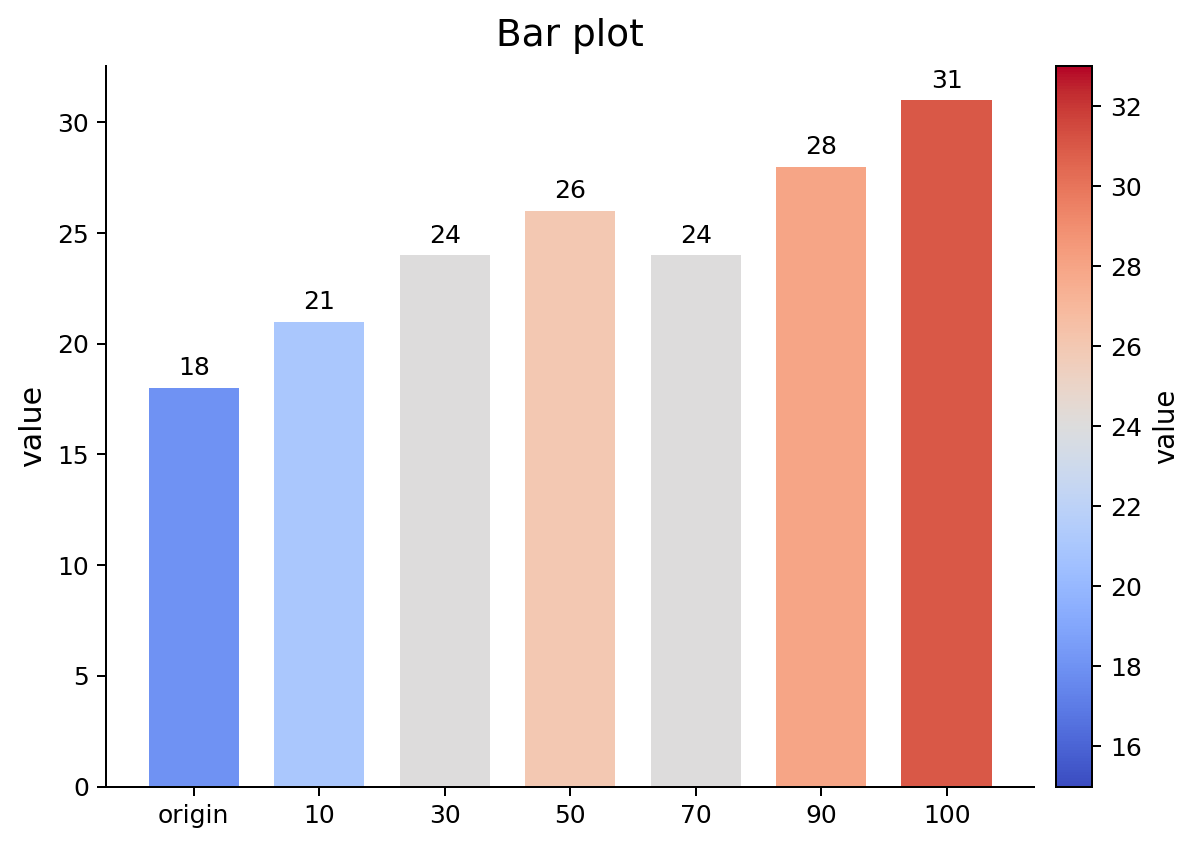

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm, colors

# Data.
labels = ["origin", "10", "30", "50", "70", "90", "100"]
values = np.array([18, 21, 24, 26, 24, 28, 31], dtype=float)

# Map values to colors: low = blue, high = red.
norm = colors.Normalize(vmin=15, vmax=33)
cmap = cm.get_cmap("coolwarm")
bar_colors = cmap(norm(values))

# Plot.
fig, ax = plt.subplots(figsize=(7, 4.8), dpi=180)
fig.patch.set_alpha(0)
ax.set_facecolor("none")

bars = ax.bar(labels, values, color=bar_colors, width=0.72)

# Numeric annotations.
for bar, v in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        v + 0.35,
        f"{int(v)}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Color bar.
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("value", fontsize=11)
cbar.ax.set_facecolor("none")

# Plot styling.
ax.set_ylabel("value", fontsize=12)
ax.set_title("Bar plot", fontsize=15, pad=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=10)

plt.tight_layout()
plt.show()

In [11]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

OUT_DIR = Path(EXPERIMENT_DIR / "artifacts/perturb/perturbation_test")

# Read 30 summary files.
files = sorted(OUT_DIR.glob("alpha_threshold_summary_seed*.csv"))
print("n_files =", len(files))

dfs = []
for f in files:
    df = pd.read_csv(f)
    df["source_file"] = f.name
    dfs.append(df)

summary_all = pd.concat(dfs, ignore_index=True)

# Inspect column names.
print(summary_all.columns.tolist())

# Extract plateau_t.
plateau_df = summary_all.loc[:, ["seed", "plateau_t"]].copy()
plateau_df["plateau_t"] = pd.to_numeric(plateau_df["plateau_t"], errors="coerce")
plateau_df = plateau_df.dropna(subset=["plateau_t"]).copy()

print(plateau_df.head())
print("n_valid =", len(plateau_df))
print(plateau_df["plateau_t"].describe())

n_files = 100
['seed', 'first_positive_t', 'plateau_t', 'plateau_level', 'sse', 'slope_left', 'intercept_left', 'perturb_num', 'zero_max_in_46', 'source_file']
   seed  plateau_t
0  2026         19
1  2027         18
2  2028         16
3  2029         17
4  2030         22
n_valid = 100
count    100.000000
mean      17.380000
std        2.013991
min       14.000000
25%       16.000000
50%       17.000000
75%       18.000000
max       29.000000
Name: plateau_t, dtype: float64


In [12]:
import numpy as np
import pandas as pd

def one_point_upper_tail_test(sample, x0):
    sample = np.asarray(sample, dtype=float)
    sample = sample[np.isfinite(sample)]
    n = len(sample)

    if n == 0:
        raise ValueError("sample is empty")

    n_greater = int(np.sum(sample > x0))
    n_geq = int(np.sum(sample >= x0))

    # Descending rank of x0.
    # If two sample values are larger, x0 ranks third.
    rank_from_top = 1 + n_greater

    # One-sided upper-tail p-value: test whether x0 is unusually high.
    p_exact_upper = rank_from_top / (n + 1)

    # Use conservative handling of ties.
    p_conservative_upper = max(1, n_geq) / (n + 1)

    return pd.Series({
        "x0": x0,
        "n": n,
        "n_greater": n_greater,
        "n_geq": n_geq,
        "rank_from_top": rank_from_top,
        "p_exact_upper": p_exact_upper,
        "p_conservative_upper": p_conservative_upper,
        "sample_min": float(np.min(sample)),
        "sample_median": float(np.median(sample)),
        "sample_max": float(np.max(sample)),
    })

y = plateau_df["plateau_t"].dropna().to_numpy(dtype=float)

# Example: test whether 31 is unusually high.
res31 = one_point_upper_tail_test(y, x0=31)
print(res31)

# Example: test the observed value 20.
res20 = one_point_upper_tail_test(y, x0=20)
print(res20)

x0                       31.000000
n                       100.000000
n_greater                 0.000000
n_geq                     0.000000
rank_from_top             1.000000
p_exact_upper             0.009901
p_conservative_upper      0.009901
sample_min               14.000000
sample_median            17.000000
sample_max               29.000000
dtype: float64
x0                       20.000000
n                       100.000000
n_greater                 5.000000
n_geq                    10.000000
rank_from_top             6.000000
p_exact_upper             0.059406
p_conservative_upper      0.099010
sample_min               14.000000
sample_median            17.000000
sample_max               29.000000
dtype: float64


In [13]:
import numpy as np
import pandas as pd

# Null distribution from 30 random knockout runs.
null_vals = plateau_df["plateau_t"].dropna().to_numpy(dtype=float)

# Observed knockout of the top 10 upregulated genes.
obs = 20.0

n = len(null_vals)
k_ge = np.sum(null_vals >= obs)   # Upper tail: count random values >= 20.

# One-sided upper-tail empirical p-value.
p_upper = (k_ge + 1) / (n + 1)

# Percentile: higher values lie farther to the right.
percentile = 100.0 * np.mean(null_vals <= obs)

print("n_null =", n)
print("obs =", obs)
print("count(null >= obs) =", int(k_ge))
print("empirical upper-tail p =", p_upper) 
print("empirical percentile =", percentile)
print("null median =", np.median(null_vals))
print("null mean =", np.mean(null_vals))

n_null = 100
obs = 20.0
count(null >= obs) = 10
empirical upper-tail p = 0.10891089108910891
empirical percentile = 95.0
null median = 17.0
null mean = 17.38


In [14]:
import numpy as np
from scipy.stats import t, shapiro

# Null distribution from 30 random knockout runs.
y = plateau_df["plateau_t"].dropna().to_numpy(dtype=float)

# Observed value.
x0 = 21.0

n = len(y)
mu = np.mean(y)
s = np.std(y, ddof=1)

# Upper-tail test of a new observation against the fitted normal distribution.
t_pred = (x0 - mu) / (s * np.sqrt(1 + 1/n))
p_upper = 1 - t.cdf(t_pred, df=n-1)

print("n =", n)
print("mean =", mu)
print("sd =", s)
print("x0 =", x0)
print("t_pred =", t_pred)
print("one-sided p (x0 is unusually high) =", p_upper)

n = 100
mean = 17.38
sd = 2.0139914637757568
x0 = 21.0
t_pred = 1.7885054099520366
one-sided p (x0 is unusually high) = 0.03837664800202678


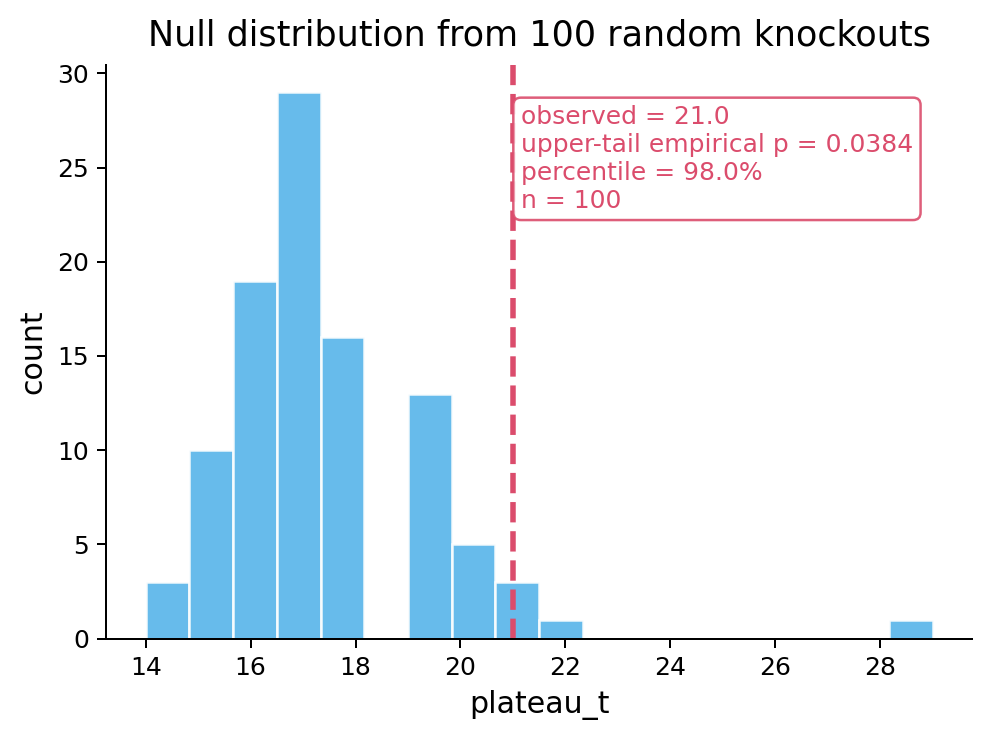

n = 100
observed = 21.0
count(y >= x0) = 5
upper-tail empirical p = 0.03837664800202678
percentile = 98.0


In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Null distribution from 100 random knockout runs.
y = plateau_df["plateau_t"].dropna().to_numpy(dtype=float)

# Observed value.
x0 = 21.0

# One-sided upper-tail empirical p-value: test whether x0 is unusually high.
n = len(y)
k_ge = np.sum(y >= x0)
t_pred = (x0 - mu) / (s * np.sqrt(1 + 1/n))
p_upper = 1 - t.cdf(t_pred, df=n-1)

# Empirical percentile.
percentile = 100 * np.mean(y <= x0)

# Plot.
fig, ax = plt.subplots(figsize=(5.6, 4.2), dpi=180)

ax.hist(
    y,
    bins="auto",
    color="#56B4E9",
    edgecolor="white",
    alpha=0.9
)

ax.axvline(
    x0,
    color="#DB4C6C",
    linestyle="--",
    linewidth=2.2
)

# Text annotations.
txt = (
    f"observed = {x0:.1f}\n"
    f"upper-tail empirical p = {p_upper:.3g}\n"
    f"percentile = {percentile:.1f}%\n"
    f"n = {n}"
)

ymax = ax.get_ylim()[1]
ax.text(
    x0 + 0.15,
    ymax * 0.93,
    txt,
    color="#DB4C6C",
    fontsize=10,
    ha="left",
    va="top",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#DB4C6C", alpha=0.9)
)

ax.set_xlabel("plateau_t", fontsize=12)
ax.set_ylabel("count", fontsize=12)
ax.set_title("Null distribution from 100 random knockouts", fontsize=14, pad=8)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

print("n =", n)
print("observed =", x0)
print("count(y >= x0) =", int(k_ge))
print("upper-tail empirical p =", p_upper)
print("percentile =", percentile)

=== Empirical null result ===
n = 100
obs = 21.0
count(y >= obs) = 5
empirical upper-tail p = 0.03837664800202678
empirical percentile = 98.0
mean = 17.38
median = 17.0
max = 29.0


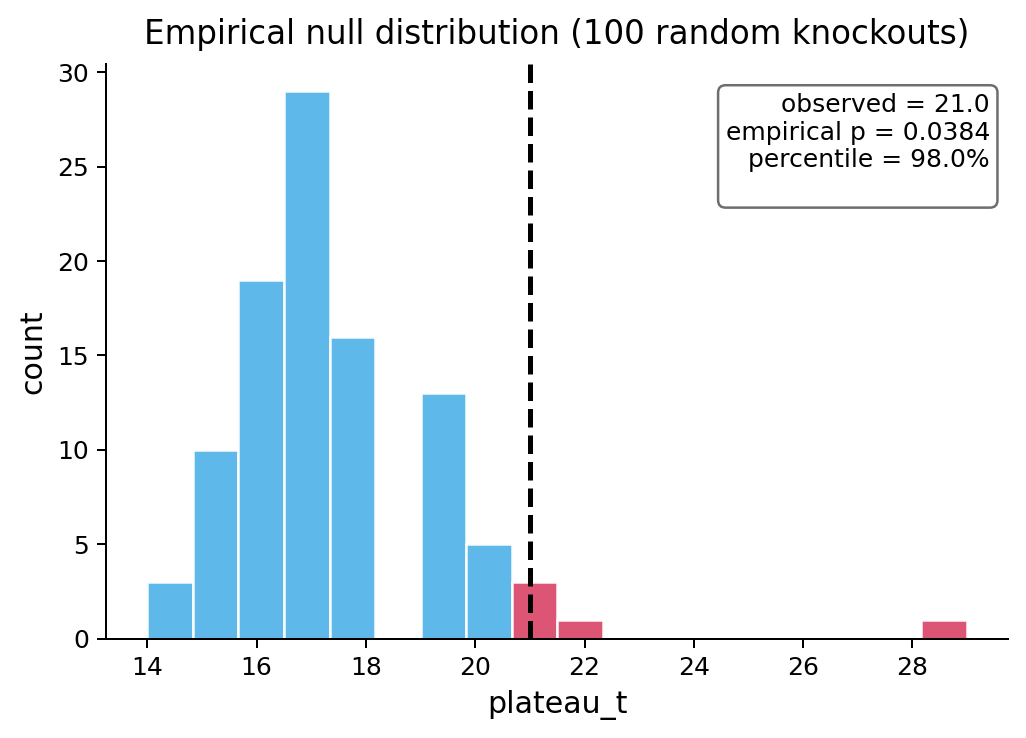

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Data.
# -----------------------------
y = plateau_df["plateau_t"].dropna().to_numpy(dtype=float)   # 100 random knockout runs.
x0 = 21.0                                                    # Observed value.

# -----------------------------
# Upper-tail test against the empirical null distribution.
# H1: x0 is higher than the random null distribution.
# -----------------------------
n = len(y)
k_ge = np.sum(y >= x0)
k_ge = np.sum(y >= x0)
t_pred = (x0 - mu) / (s * np.sqrt(1 + 1/n))
p_upper = 1 - t.cdf(t_pred, df=n-1)
percentile = 100 * np.mean(y <= x0)

print("=== Empirical null result ===")
print("n =", n)
print("obs =", x0)
print("count(y >= obs) =", int(k_ge))
print("empirical upper-tail p =", p_upper)
print("empirical percentile =", percentile)
print("mean =", np.mean(y))
print("median =", np.median(y))
print("max =", np.max(y))

# -----------------------------
# Plot the null distribution, observed value, and p-value.
# -----------------------------
fig, ax = plt.subplots(figsize=(5.8, 4.2), dpi=180)

counts, bins, patches = ax.hist(
    y,
    bins="auto",
    edgecolor="white",
    alpha=0.95
)

# Highlight the right tail.
for left, right, patch in zip(bins[:-1], bins[1:], patches):
    center = 0.5 * (left + right)
    if center >= x0:
        patch.set_facecolor("#DB4C6C")
    else:
        patch.set_facecolor("#56B4E9")

ax.axvline(x0, color="black", linestyle="--", linewidth=2)

txt = (
    f"observed = {x0:.1f}\n"
    f"empirical p = {p_upper:.3g}\n"
    f"percentile = {percentile:.1f}%\n"
)

ax.text(
    0.98, 0.95, txt,
    transform=ax.transAxes,
    ha="right", va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.4", alpha=0.95)
)

ax.set_xlabel("plateau_t", fontsize=12)
ax.set_ylabel("count", fontsize=12)
ax.set_title("Empirical null distribution (100 random knockouts)", fontsize=13, pad=8)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

=== Empirical null result ===
n = 100
obs = 21.0
count(y >= obs) = 5
empirical upper-tail p = 0.0594059405940594
empirical percentile = 98.0
mean = 17.38
median = 17.0
max = 29.0


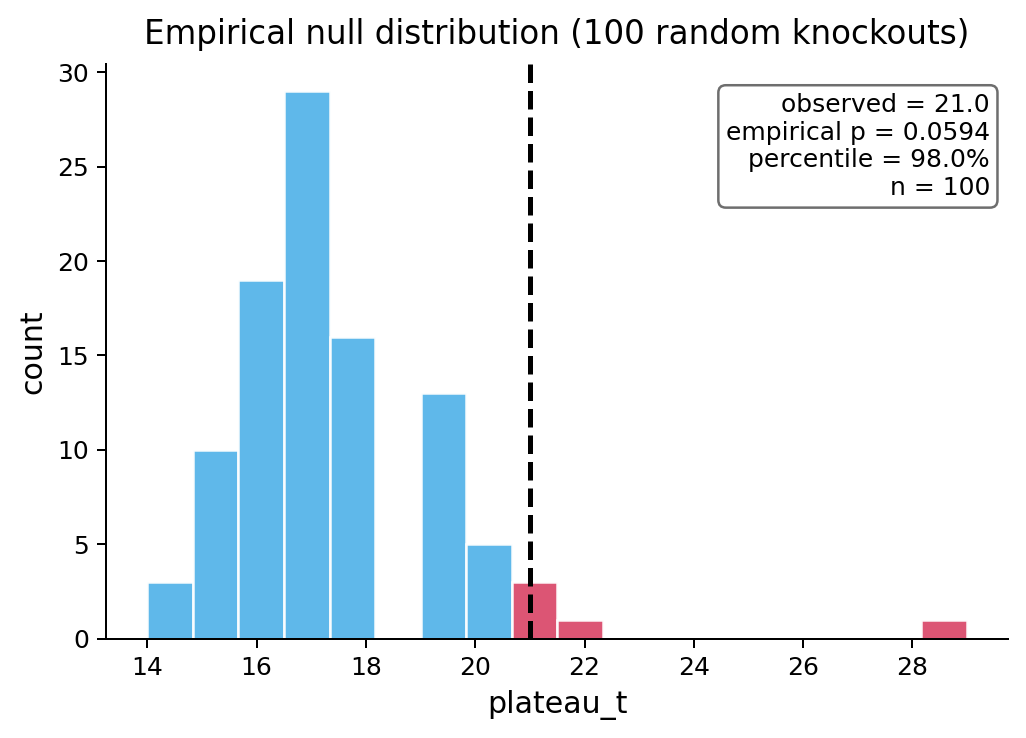

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Data.
# -----------------------------
y = plateau_df["plateau_t"].dropna().to_numpy(dtype=float)   # 100 random knockout runs.
x0 = 21.0                                                    # Observed value.

# -----------------------------
# Upper-tail test against the empirical null distribution.
# H1: x0 is higher than the random null distribution.
# -----------------------------
n = len(y)
k_ge = np.sum(y >= x0)
p_upper = (k_ge + 1) / (n + 1)   # Empirical p-value.
percentile = 100 * np.mean(y <= x0)

print("=== Empirical null result ===")
print("n =", n)
print("obs =", x0)
print("count(y >= obs) =", int(k_ge))
print("empirical upper-tail p =", p_upper)
print("empirical percentile =", percentile)
print("mean =", np.mean(y))
print("median =", np.median(y))
print("max =", np.max(y))

# -----------------------------
# Plot the null distribution, observed value, and p-value.
# -----------------------------
fig, ax = plt.subplots(figsize=(5.8, 4.2), dpi=180)

counts, bins, patches = ax.hist(
    y,
    bins="auto",
    edgecolor="white",
    alpha=0.95
)

# Highlight the right tail.
for left, right, patch in zip(bins[:-1], bins[1:], patches):
    center = 0.5 * (left + right)
    if center >= x0:
        patch.set_facecolor("#DB4C6C")
    else:
        patch.set_facecolor("#56B4E9")

ax.axvline(x0, color="black", linestyle="--", linewidth=2)

txt = (
    f"observed = {x0:.1f}\n"
    f"empirical p = {p_upper:.3g}\n"
    f"percentile = {percentile:.1f}%\n"
    f"n = {n}"
)

ax.text(
    0.98, 0.95, txt,
    transform=ax.transAxes,
    ha="right", va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.4", alpha=0.95)
)

ax.set_xlabel("plateau_t", fontsize=12)
ax.set_ylabel("count", fontsize=12)
ax.set_title("Empirical null distribution (100 random knockouts)", fontsize=13, pad=8)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

=== Empirical null after removing max value ===
removed max = 29.0
n_trim = 99
obs = 21.0
count(y_trim >= obs) = 4
empirical upper-tail p = 0.04040404040404041


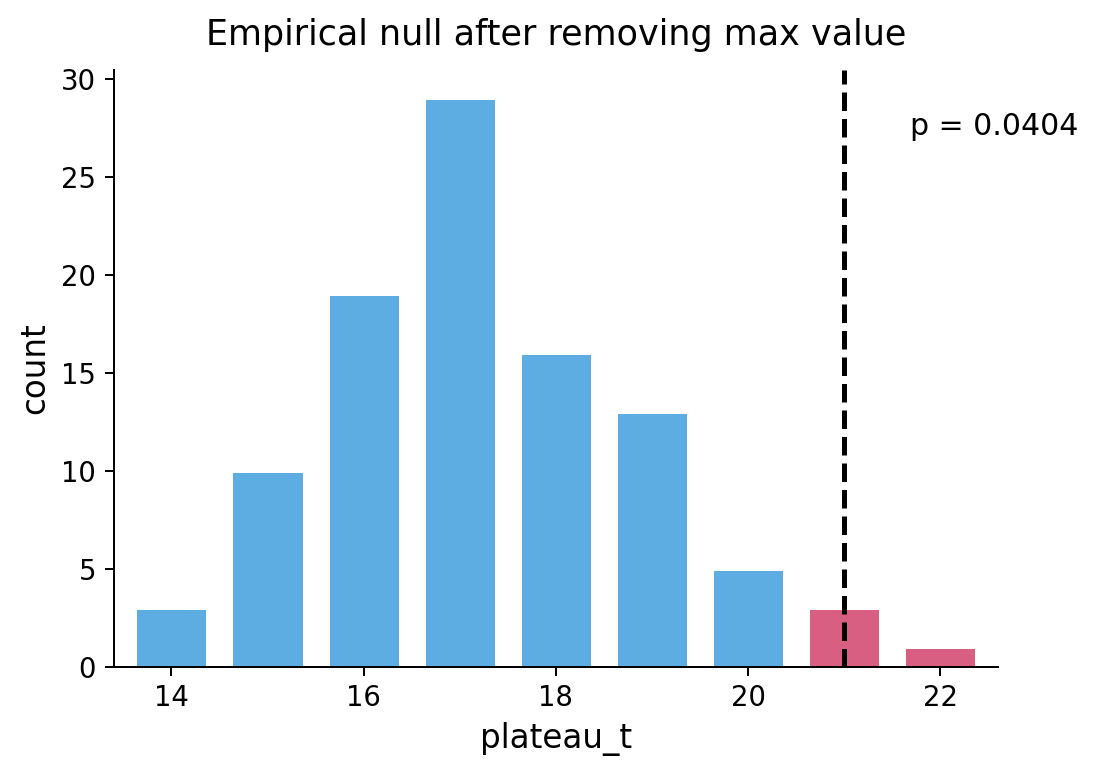

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# -----------------------------
# Original data.
# -----------------------------
y = plateau_df["plateau_t"].dropna().to_numpy(dtype=float)
x0 = 21.0

# -----------------------------
# Remove the maximum value.
# -----------------------------
y_trim = np.sort(y)[:-1].copy()

# -----------------------------
# Uncorrected empirical upper-tail p-value.
# -----------------------------
n_trim = len(y_trim)
k_ge_trim = np.sum(y_trim >= x0)   # Use > for a strict comparison.
p_upper_trim = k_ge_trim / n_trim

print("=== Empirical null after removing max value ===")
print("removed max =", np.max(y))
print("n_trim =", n_trim)
print("obs =", x0)
print("count(y_trim >= obs) =", int(k_ge_trim))
print("empirical upper-tail p =", p_upper_trim)

# -----------------------------
# Frequency counts.
# -----------------------------
cnt = Counter(y_trim)
xs = np.array(sorted(cnt.keys()))
ys = np.array([cnt[v] for v in xs])

colors = np.where(xs >= x0, "#D95F82", "#5DADE2")

# Bar width.
if len(xs) > 1:
    width = 0.75 * np.min(np.diff(np.unique(xs)))
else:
    width = 0.6

# -----------------------------
# Plot.
# -----------------------------
fig, ax = plt.subplots(figsize=(6.2, 4.4), dpi=180)

ax.bar(
    xs,
    ys,
    width=width,
    color=colors,
    edgecolor="white",
    linewidth=1.2
)

# Vertical line for the observed value.
ax.axvline(x0, color="black", linestyle="--", linewidth=2)

# Place the p-value in the upper left without a box, away from the vertical line.
ax.text(
    0.90, 0.93,
    f"p = {p_upper_trim:.4f}",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=12
)

# Plot styling.
ax.set_xlabel("plateau_t", fontsize=13)
ax.set_ylabel("count", fontsize=13)
ax.set_title("Empirical null after removing max value", fontsize=14, pad=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(labelsize=11)
# ax.grid(axis="y", linestyle=":", alpha=0.25)

ax.set_xlim(xs.min() - 0.6, xs.max() + 0.6)

plt.tight_layout()
plt.show()

=== One-sided t test under normal assumption ===
removed max = 29.0
n = 99
mean = 17.262626262626263
sd = 1.6449418982720914
observed = 21.0
t_pred = 2.260651224438555
upper-tail p = 0.012996345199610349


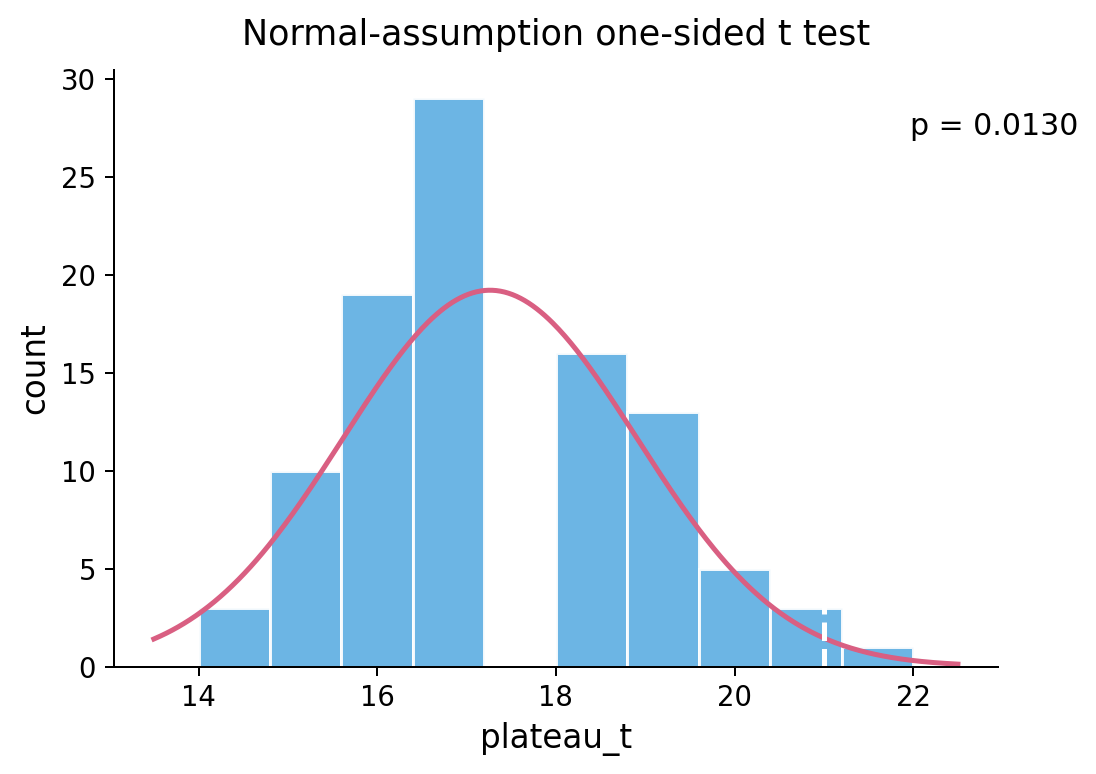

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, norm

# -----------------------------
# Original data.
# -----------------------------
y = plateau_df["plateau_t"].dropna().to_numpy(dtype=float)
x0 = 21.0

# -----------------------------
# Remove the maximum value.
# -----------------------------
y_trim = np.sort(y)[:-1].copy()

# -----------------------------
# Normal assumption: one-sided upper-tail predictive t-test.
# H0: x0 follows the same normal null distribution as y_trim.
# H1: x0 is unusually high.
# -----------------------------
n = len(y_trim)
mu = np.mean(y_trim)
s = np.std(y_trim, ddof=1)

t_pred = (x0 - mu) / (s * np.sqrt(1 + 1/n))
p_upper_t = 1 - t.cdf(t_pred, df=n-1)

print("=== One-sided t test under normal assumption ===")
print("removed max =", np.max(y))
print("n =", n)
print("mean =", mu)
print("sd =", s)
print("observed =", x0)
print("t_pred =", t_pred)
print("upper-tail p =", p_upper_t)

# -----------------------------
# Plot a histogram and fitted normal curve.
# -----------------------------
fig, ax = plt.subplots(figsize=(6.2, 4.4), dpi=180)
fig.patch.set_alpha(0)
ax.set_facecolor("none")

# Histogram.
counts, bins, _ = ax.hist(
    y_trim,
    bins=10,
    color="#5DADE2",
    edgecolor="white",
    linewidth=1.2,
    alpha=0.9
)

# Fit a normal curve scaled to frequency counts.
xx = np.linspace(min(y_trim) - 0.5, max(y_trim) + 0.5, 400)
bin_width = bins[1] - bins[0]
yy = norm.pdf(xx, loc=mu, scale=s) * n * bin_width
ax.plot(xx, yy, color="#D95F82", linewidth=2)

# Vertical line for the observed value.
ax.axvline(x0, color="white", linestyle="--", linewidth=2)

# p-value.
ax.text(
    0.90, 0.93,
    f"p = {p_upper_t:.4f}",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=12
)

# Plot styling.
ax.set_xlabel("plateau_t", fontsize=13)
ax.set_ylabel("count", fontsize=13)
ax.set_title("Normal-assumption one-sided t test", fontsize=14, pad=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(labelsize=11)

plt.tight_layout()
plt.show()

## Inspect a selected comparison

Choose two diagnostic tables and plot their trajectories.


In [178]:
dia0 = pd.read_csv(EXPERIMENT_DIR / "artifacts/perturb/origin/diag_piece1.csv")
dia1 = pd.read_csv(EXPERIMENT_DIR / "artifacts/perturb/top10_results/diag_piece1.csv")


In [179]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_prop_clean_two(
    diag_df1,
    diag_df2,
    t_col="t_step",
    prop_col="prop_alpha_gt_0.6",
    plateau_t1=None,
    plateau_t2=None,
    label1="diag_df1",
    label2="diag_df2",
    figsize=(6.2, 4.8),
    dpi=180,
    ylim=(0, 0.6),
):
    line_color1 = "#1f77b4"   # Blue.
    line_color2 = "#ff7f0e"   # Orange.
    mark_color1 = "#1f77b4"   # Blue.
    mark_color2 = "#ff7f0e"    # Orange.

    def _prep_xy(diag_df):
        x = pd.to_numeric(diag_df[t_col], errors="coerce").to_numpy()
        y = pd.to_numeric(diag_df[prop_col], errors="coerce").to_numpy()
        ok = np.isfinite(x) & np.isfinite(y)
        x = x[ok]
        y = y[ok]
        order = np.argsort(x)
        return x[order], y[order]

    def _get_y_at_t(diag_df, t_value):
        if t_value is None:
            return None
        sub = diag_df.loc[
            pd.to_numeric(diag_df[t_col], errors="coerce") == t_value,
            prop_col
        ]
        if len(sub) == 0:
            return None
        val = pd.to_numeric(sub, errors="coerce").iloc[0]
        return float(val) if pd.notna(val) else None

    x1, y1 = _prep_xy(diag_df1)
    x2, y2 = _prep_xy(diag_df2)

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    # ---------- First curve. ----------
    # ax.fill_between(x1, y1, 0, color=line_color1, alpha=0.14, zorder=1)
    ax.plot(x1, y1, color=line_color1, lw=2.3, zorder=3, label=label1)

    y1_pl = _get_y_at_t(diag_df1, plateau_t1)
    if y1_pl is not None:
        ax.axvline(plateau_t1, color=mark_color1, ls="--", lw=1.5, alpha=0.9, zorder=2)
        ax.scatter(
            [plateau_t1], [y1_pl],
            s=75, color=mark_color1, edgecolor="white", linewidth=0.9, zorder=4
        )

    # ---------- Second curve. ----------
    # ax.fill_between(x2, y2, 0, color=line_color2, alpha=0.10, zorder=1)
    ax.plot(x2, y2, color=line_color2, lw=2.3, zorder=3, label=label2)

    y2_pl = _get_y_at_t(diag_df2, plateau_t2)
    if y2_pl is not None:
        ax.axvline(plateau_t2, color=mark_color2, ls="--", lw=1.5, alpha=0.9, zorder=2)
        ax.scatter(
            [plateau_t2], [y2_pl],
            s=75, color=mark_color2, edgecolor="white", linewidth=0.9, zorder=4
        )

    # ---------- Axis styling. ----------
    ax.set_xlabel("t", fontsize=12)
    ax.set_ylabel("proportion", fontsize=12)
    ax.set_title(prop_col, fontsize=15, pad=8)
    ax.set_ylim(*ylim)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.0)
    ax.spines["bottom"].set_linewidth(1.0)
    ax.tick_params(axis="both", labelsize=10)

    # ax.legend(frameon=False, fontsize=10)
    plt.tight_layout()
    plt.show()

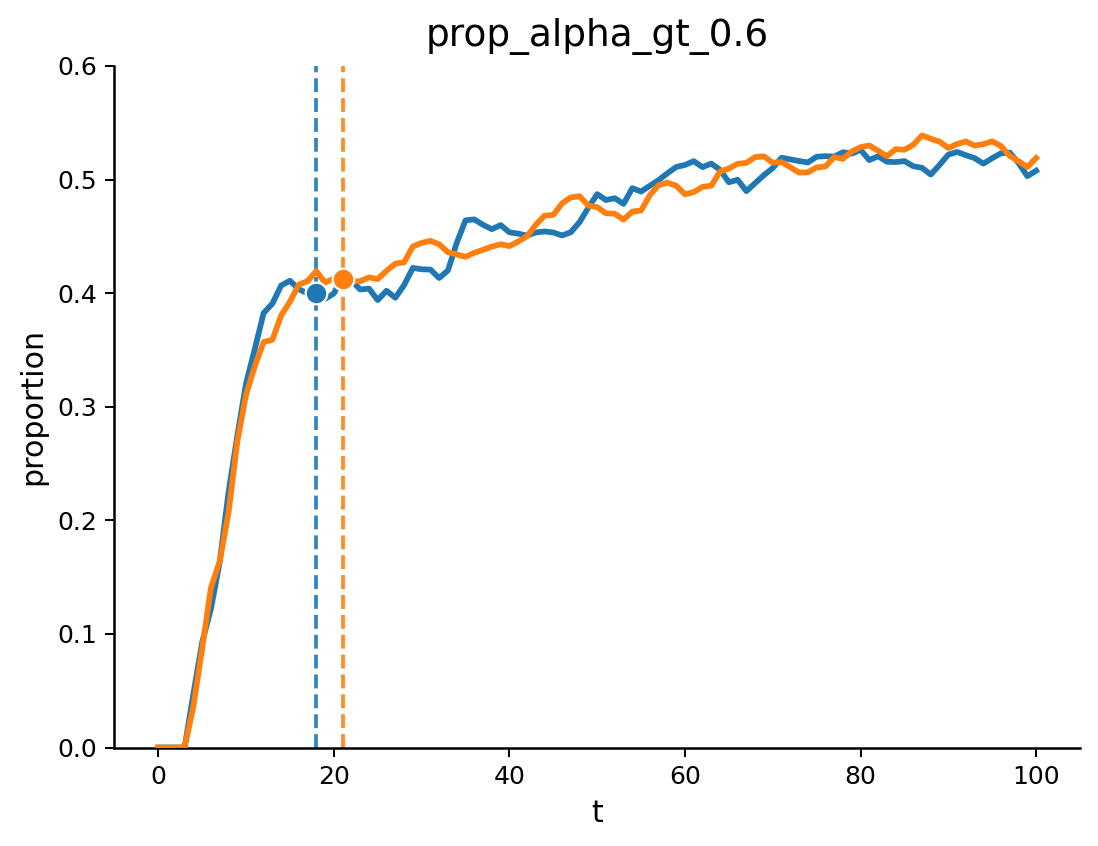

In [180]:
plot_prop_clean_two(
    diag_df1=dia0,
    diag_df2=dia1,
    t_col="t_step",
    prop_col="prop_alpha_gt_0.6",
    plateau_t1=18,
    plateau_t2=21,
    label1="raw",
    label2="perturbed",
)